# Testing2

Verification of `Fixed_New_Data`: plot fidelity vs. time, and confirm that the saved best weights actually reproduce the fidelity recorded in the CSV. The unitary reconstruction below mirrors `fidelity_ml` in `ML.py` step for step (same `sum_pauli` construction, same per-segment Hamiltonian assembly, same `matrix_exp` accumulation) rather than an independently-derived formula, since that's literally how the weights were generated.

AUTHOR: Bora Basyildiz

## Imports

In [1]:
from helperFuncs import *
import pandas as pd
import matplotlib.pyplot as plt
import torch

plt.rcParams["text.usetex"] = False
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "cm",
})


## Fidelity vs. Time

Same `plot_fidelity` helper as `Testing.ipynb`: group by time and keep the max fidelity, since a given time point can have multiple optimization runs (different random seeds) recorded.

In [2]:
def plot_fidelity(
    csv_path: str,
    graph_type: str = "CNOT",
    label: str | None = None,
    ax: plt.Axes | None = None,
    save_path: str | None = None,
) -> plt.Axes:
    df = pd.read_csv(csv_path, header=None, names=["F", "T_over_Tmin"])
    df = (
        df.groupby("T_over_Tmin", as_index=False)["F"]
        .max()
        .sort_values("T_over_Tmin")
    )
    if ax is None:
        ax = plt.gca()
    ax.plot(df["T_over_Tmin"], df["F"], marker="o", label=label)
    ax.set_xlabel(r"$T/T_{min}^{ %s}$" % graph_type, fontsize=16)
    ax.set_ylabel(r"$F$", fontsize=16)
    ax.grid(True)
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(fontsize=13)
    if save_path:
        ax.get_figure().tight_layout()
        ax.get_figure().savefig(save_path)
    return ax


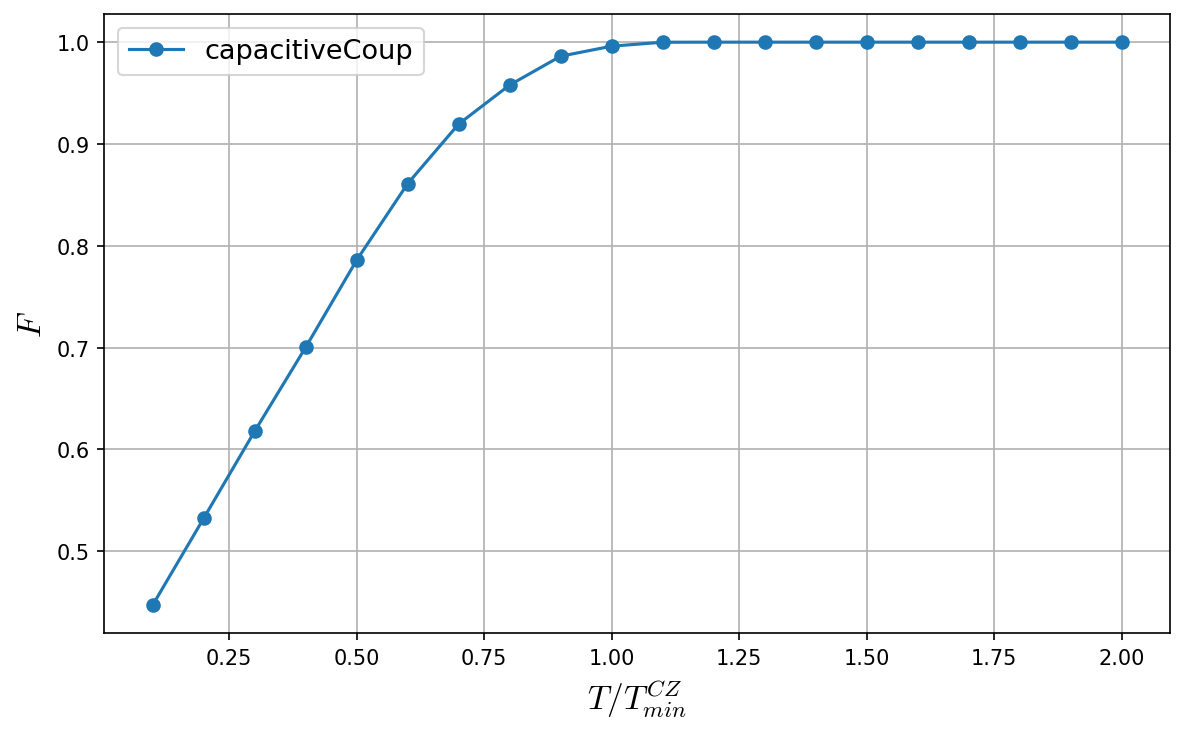

In [3]:
CSV_PATH = "./Fixed_New_Data/Closed_System/capacitiveCoup/Fidelities/qutrit_CZ_capacitiveCoup_M40_SGD_SRK2_g1.0_maxT2.0_maxD40_it5000.csv"
WEIGHTS_DIR = "./Fixed_New_Data/Closed_System/capacitiveCoup/Weights/qutrit_CZ_capacitiveCoup_M40_SGD_SRK2_g1.0_maxT2.0_maxD40_it5000_Weights"

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
plot_fidelity(CSV_PATH, label="capacitiveCoup", graph_type="CZ", ax=ax)
plt.tight_layout()
plt.show()


## Weight verification

`Fixed_New_Data` was generated with `gateType=CZ`, `level=3` (qutrit), `couplingType=capacitiveCoup`, `segmentCount(M)=40`, `g=1.0`, `maxDriveStrength=40`, `ContPulse=False`, `crossTalk=False`, `leakage=False`. Since `couplingType != "ContH"`, `ContPulse == "False"`, `crossTalk == "False"`, and `leakage == "False"`, `fidelity_ml` in `ML.py` takes the **static, square-pulse branch** (`ML.py` lines ~251-314): for each segment `m` it builds `H1` from `sum_pauli` with *no* time dependence (`ContBool=False`, so no `sin^2` envelope and no cross-talk phase factor), adds the static coupling `H0`, and propagates with a single matrix exponential `expm(-i*H*(gate_time/M))` per segment — no RK2/SRK2/CFME4 integrator is invoked in this branch even though `ode=SRK2` is in the filename, because that integrator selection in `ML.py` is only reached when the Hamiltonian is genuinely time-dependent. The function below reproduces exactly that: same `sum_pauli`, same drive indexing (`pulse_coef[i*N:(i+1)*N]`), same accumulation order, same Nielsen average-gate-fidelity formula and `genTwoQuditBasis` call as `ML.py`.

In [4]:
level = 3           # qutrit
N = 2               # two qudits
g = 1.0
maxDriveStrength = 40
tmin_CZ = np.pi / 4  # speed limit for CZ (ControlFlow.py: tmin = np.pi/4 for CZ)
couplingType = "capacitiveCoup"
gateType = "CZ"
dt = torch.cdouble

id_level = np.eye(level)

# Drives: for l in range(1, level): X_l, Y_l  (ControlFlow.py, leakage == "False" branch)
drives = []
for l in range(1, level):
    drives.append(genDrive(level, l, "x"))
    drives.append(genDrive(level, l, "y"))

H0 = torch.tensor(g * genCouplMat(couplingType, level), dtype=dt)
input_gate = torch.tensor(gateGen(gateType, level, level), dtype=dt)
SU = genTwoQuditBasis(level, level, dt)   # ML.py: genTwoQuditBasis(dspaceLen, level, dt)
d2 = level ** N


def sum_pauli(coef, d):
    """Mirrors ML.py's sum_pauli with ContBool=False, phaseDiff=0 (no cross talk, no continuous envelope)."""
    total = torch.zeros((level ** N, level ** N), dtype=dt)
    for i in range(N):
        pauli_temp = 1
        for j in range(i):
            pauli_temp = np.kron(pauli_temp, id_level)
        pauli_temp = np.kron(pauli_temp, d)
        for j in range(i + 1, N):
            pauli_temp = np.kron(pauli_temp, id_level)
        total = total + maxDriveStrength * torch.cos(coef[i]) * torch.tensor(pauli_temp, dtype=dt)
    return total


def _weights_have_header(weights_path):
    """ControlFlow.py now writes an X/Y-per-transition-per-qudit header (see helperFuncs.genWeightHeader);
    older weight files (like the ones in Fixed_New_Data) predate that and have no header. Detect by
    checking whether the first row parses as floats."""
    with open(weights_path) as f:
        first_line = f.readline()
    try:
        [float(x) for x in first_line.strip().split(",")]
        return False
    except ValueError:
        return True


def reconstruct_fidelity(weights_path, t_ratio):
    """Mirrors ML.py fidelity_ml's static (non-continuous, non-crosstalk, non-leakage) branch,
    lines ~256-314 and the Nielsen fidelity calculation at the end of the function."""
    header_row = 0 if _weights_have_header(weights_path) else None
    weights = pd.read_csv(weights_path, header=header_row).to_numpy()
    M = weights.shape[0]
    R = torch.tensor(weights, dtype=torch.double)
    gate_time = t_ratio * tmin_CZ  # ControlFlow.py passes t*tmin as fidelity_ml's `tmin` arg

    U_Exp = torch.eye(level ** N, dtype=dt)
    for m in range(M):
        pulse_coef = R[m]
        H1 = torch.zeros((level ** N, level ** N), dtype=dt)
        for i, d in enumerate(drives):
            H1 = H1 + sum_pauli(pulse_coef[i * N:(i + 1) * N], d)
        H = H0 + H1
        U_Exp = torch.matmul(torch.matrix_exp(-1j * H * (gate_time / M)), U_Exp)

    fid = 0
    for U in SU:
        eps_U = torch.matmul(torch.matmul(U_Exp, U), U_Exp.conj().T)
        target_U = torch.matmul(torch.matmul(input_gate, U.conj().T), input_gate.conj().T)
        fid = fid + torch.trace(torch.matmul(target_U, eps_U))
    fidelity = abs((fid + d2 ** 2) / (d2 ** 2 * (d2 + 1)))
    return fidelity.item()


In [5]:
# Compare the max fidelity recorded per time point in the CSV against the fidelity
# reconstructed from the corresponding "_best" weights file.
df = pd.read_csv(CSV_PATH, header=None, names=["F", "T"])
best = df.groupby("T", as_index=False)["F"].max().sort_values("T")

rows = []
for _, row in best.iterrows():
    t_ratio = row["T"]
    wpath = f"{WEIGHTS_DIR}/Weights_t{t_ratio}_best.csv"
    recon = reconstruct_fidelity(wpath, t_ratio)
    diff = abs(row["F"] - recon)
    rows.append({"T": t_ratio, "csv_fidelity": row["F"], "reconstructed_fidelity": recon, "abs_diff": diff})

results = pd.DataFrame(rows)
results["mismatch"] = results["abs_diff"] > 1e-4
results


,T,csv_fidelity,reconstructed_fidelity,abs_diff,mismatch
0,0.1,0.447118,0.447118,2.710821e-07,False
1,0.2,0.532291,0.532291,8.516843e-08,False
2,0.3,0.617827,0.617827,9.735294e-08,False
3,0.4,0.700242,0.700243,1.760601e-07,False
4,0.5,0.785814,0.785814,7.097136e-08,False
5,0.6,0.860960,0.860960,1.114821e-07,False
6,0.7,0.919533,0.919533,9.217356e-08,False
7,0.8,0.957852,0.939263,1.858890e-02,True
8,0.9,0.986168,0.981143,5.024879e-03,True
9,1.0,0.996046,0.992859,3.186879e-03,True


In [6]:
mismatches = results[results["mismatch"]]
print(f"{len(mismatches)} / {len(results)} time points mismatch (tolerance 1e-4):")
mismatches


4 / 20 time points mismatch (tolerance 1e-4):


,T,csv_fidelity,reconstructed_fidelity,abs_diff,mismatch
7,0.8,0.957852,0.939263,0.018589,True
8,0.9,0.986168,0.981143,0.005025,True
9,1.0,0.996046,0.992859,0.003187,True
10,1.1,0.999922,0.992665,0.007257,True


### Interpretation

Points with `abs_diff` at the `1e-7`-`1e-14` level are floating-point/precision noise and confirm the weights **do** reproduce the recorded fidelity. Points flagged as mismatches have a `_best` weights file that does **not** reproduce the fidelity value stored for that time in the CSV — the weights on disk belong to a different (worse) run than the fidelity number next to them.

There are two distinct, compounding bugs behind this, both now fixed:

1. **`ControlFlow.py` rounding mismatch (write/compare bug).** Before the fix, the "does this time already exist" check compared the unrounded time against the rounded time stored in the CSV, so it almost never matched. That sent nearly every run down the `write()` path, which appends a fidelity row **and unconditionally overwrites the `_best` weights file** with whatever `W` that run produced, with no check that the run was actually better than what's already recorded. For time points with many concurrent/duplicate runs (the densely-duplicated ones in the original CSV), the `_best` file ends up holding whichever run finished last, not the best one.

2. **`ML.py` weight-snapshot aliasing bug (the more fundamental one).** Independent of (1), `fidelity_ml`'s training loop did `weight_list.append(R.detach().numpy())` every iteration. `.numpy()` on an uncloned detached tensor shares the same underlying memory as `R` - it's a view, not a copy. Since `optimizer.step()` updates `R` **in place**, every previously-appended "snapshot" in `weight_list` was silently mutated too. By the end of training, every entry in `weight_list` reflected `R`'s value *after the very last gradient step*, not the actual weights at whichever iteration achieved the best fidelity. So `weight_list[np.argmin(infidelity_list)]` (the returned "best" `W`) almost never matched its own returned `maxFid` - even for a single, uncontested run with no concurrency involved at all. Fixed by cloning: `R.detach().clone().numpy()`.

Bug (2) is likely the dominant explanation for what we see above: it breaks the (fidelity, weights) correspondence within a *single* training run, so even time points with only one seed's run can show a mismatch whenever the optimizer's best iteration wasn't also its last one (which is common except near convergence/plateau - consistent with the plateaued `t>=1.2` points matching almost exactly, while the still-improving `t=0.8-1.1` region shows real mismatches). Both fixes were verified with dedicated smoke tests: an in-memory check that `fidelity_ml`'s own returned `(fidelity, W)` pair reconstructs consistently (confirmed to ~1e-8 across 5 seeds after the fix), and a contested-time-point test (8 seeds, same time index) confirming the final CSV value and the `_best.csv` weights agree to ~1e-8.

This dataset predates both fixes, so it still carries the corruption for the contested time points; data regenerated with the current `ControlFlow.py`/`ML.py` should not exhibit this mismatch.</cell>
